In [3]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
# Load the Excel file using pandas
df = pd.read_excel('G:/OPC-mortar/ALLdata.xlsx')

# Display the dataframe
df

,LOI (%),SiO2 (%),Al2O3 (%),Fe2O3 (%),CaO (%),MgO (%),SO3 (%),Na2O (%),K2O (%),C3S,C2S,C3A,‍‍‍C4AF,Blaine (m2/kg),Setting int (min),Setting final (min),28-days CS (MPa)
0,1.09,20.97,5.26,4.00,63.09,1.61,2.29,0.33,0.74,46.7798,24.911931,7.17100,12.17200,331.0,167.0,236.0,50.6
1,0.98,20.85,5.18,3.98,63.30,1.67,2.36,0.32,0.74,48.9110,22.960606,6.99284,12.11114,323.0,173.0,235.0,52.4
2,0.93,21.22,5.25,3.94,63.86,1.66,2.44,0.31,0.75,47.7372,24.907551,7.24602,11.98942,331.0,174.0,240.0,54.8
3,0.98,20.92,5.18,4.02,63.09,1.65,2.47,0.32,0.73,47.1548,24.485681,6.92516,12.23286,319.0,165.0,219.0,50.6
4,0.91,20.79,5.12,4.06,63.20,1.65,2.42,0.31,0.74,49.0790,22.661734,6.69848,12.35458,331.0,166.0,220.0,52.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,2.30,0.96,0.48,2.78,1.86,62.52,3.66,4.90,20.48,11.1264,6.799600,19.17235,52.80700,336.0,170.0,120.0,26.8
309,2.26,0.94,0.55,2.76,1.88,62.50,3.68,4.88,20.54,11.1872,6.712800,19.62595,52.43180,335.0,160.0,117.0,27.7
310,2.30,0.96,0.54,2.74,1.90,62.46,3.68,4.90,20.58,11.1872,6.765800,20.14935,51.88700,334.0,160.0,120.0,26.5
311,2.28,0.94,0.54,2.80,1.88,62.54,3.66,4.88,20.50,11.1264,6.746600,19.22420,52.81440,330.0,160.0,122.0,27.1


In [7]:
# Checking for missing values
missing_values = df.isnull().sum()

# Displaying the number of missing values for each column (it will show the sum
# of the number of missing values rows for each column)
print("Missing values in each column:")
missing_values

Missing values in each column:


LOI (%)                0
SiO2 (%)               0
Al2O3 (%)              0
Fe2O3 (%)              0
CaO (%)                0
MgO (%)                0
SO3 (%)                0
Na2O (%)               0
K2O (%)                0
C3S                    0
C2S                    0
C3A                    0
‍‍‍C4AF                0
Blaine (m2/kg)         0
Setting int (min)      0
Setting final (min)    0
28-days CS (MPa)       0
dtype: int64

In [9]:
# Remove all rows containing missing values
df_cleaned = df.dropna()
df[df.duplicated(keep=False)]

,LOI (%),SiO2 (%),Al2O3 (%),Fe2O3 (%),CaO (%),MgO (%),SO3 (%),Na2O (%),K2O (%),C3S,C2S,C3A,‍‍‍C4AF,Blaine (m2/kg),Setting int (min),Setting final (min),28-days CS (MPa)


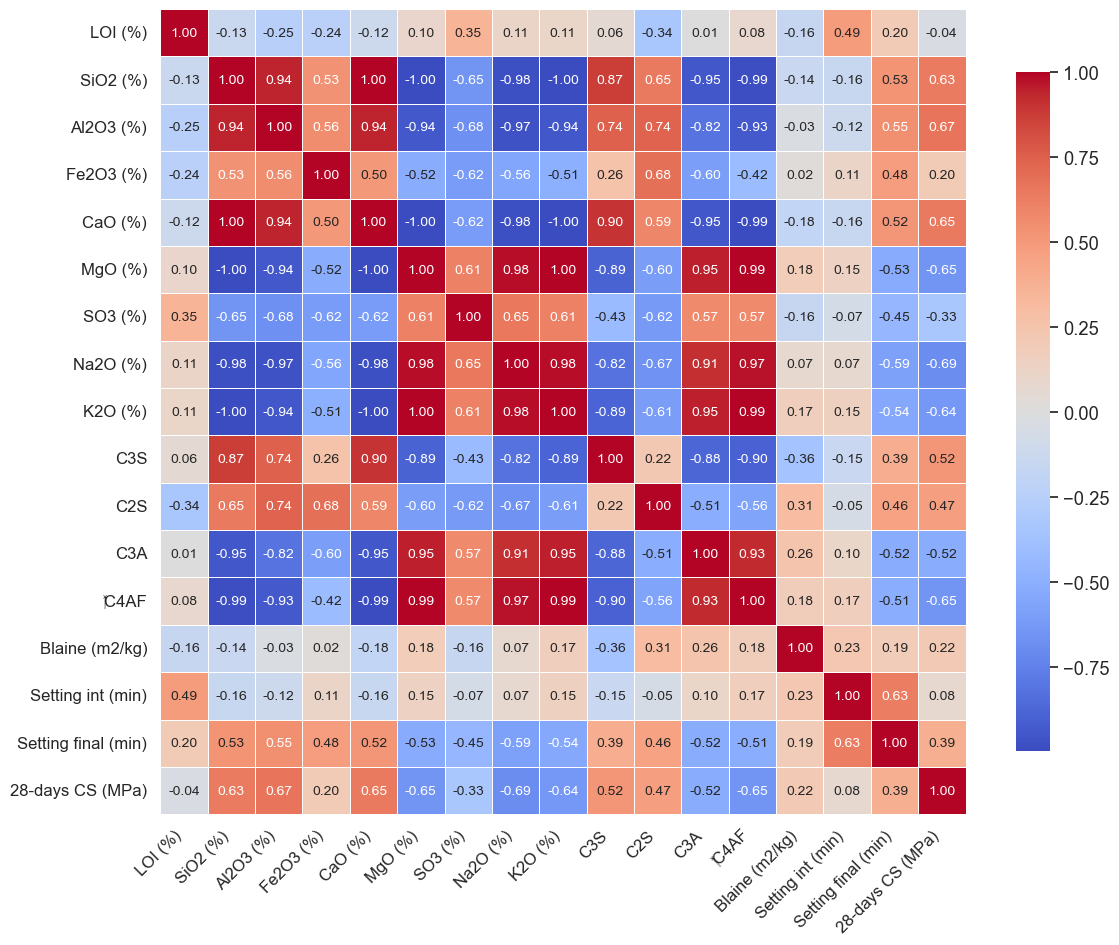

In [13]:
#Pearson Correlation

# Set a larger default font size for all text elements (optional but helpful)
sns.set(font_scale=1.2)  # Adjust this scale factor as needed

# Compute correlation matrix
corr_matrix = df_cleaned.corr()

# Create figure with appropriate size
plt.figure(figsize=(12, 10))  # Slightly taller to accommodate larger labels

# Generate heatmap with diverging colormap, e.g., 'coolwarm'
# center=0 ensures white at zero correlation
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',      # diverging colormap: red=positive, blue=negative
            center=0,             # center the colormap at 0
            fmt='.2f',            # optional: format annotations to 2 decimals
            square=True,          # optional: make cells square for better appearance
            linewidths=0.5,       # optional: add lines between cells
            cbar_kws={"shrink": 0.8},  # optional: shrink colorbar a bit
            annot_kws={"size": 10})    # optional: increase annotation font size

# Rotate x-axis labels if they overlap (optional)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Tight layout to ensure everything fits
plt.tight_layout()

plt.show()

In [15]:
# This block is created to get more information about dataset and the requirements for PCA

#setting feature and target
X = df.drop(columns=["28-days CS (MPa)"])   
y = df["28-days CS (MPa)"]

feature_names = X.columns.to_list()
target_names = y.unique()

def analyze_dimensionality(data, feature_names, target):
    """Analyze high-dimensional data characteristics."""

    # Ensure NumPy array
    if hasattr(data, "to_numpy"):
        data_array = data.to_numpy()
    else:
        data_array = data

    n_samples, n_features = data_array.shape

    print(f"\nDimensionality Analysis:")
    print(f"Features: {n_features}, Samples: {n_samples}")
    print(f"Sample-to-feature ratio: {n_samples/n_features:.2f}")

    # Feature scale analysis
    feature_scales = [np.ptp(data_array[:, i]) for i in range(n_features)]

    min_scale = np.min(feature_scales)
    scale_ratio = np.inf if min_scale == 0 else np.max(feature_scales) / min_scale

    print(f"\nFeature Scale Analysis:")
    print(f"Scale ratio (max/min): {scale_ratio:.2f}")
    if scale_ratio > 100:
        print("Large scale differences - standardization needed")

    # Correlation analysis
    corr_matrix = np.corrcoef(data_array.T)
    upper_triangle = np.triu(corr_matrix, k=1)
    high_corr_count = np.sum(np.abs(upper_triangle) > 0.8)
    total_pairs = (n_features * (n_features - 1)) // 2

    print(f"\nCorrelation Analysis:")
    print(
        f"High correlations (|r| > 0.8): "
        f"{high_corr_count} ({high_corr_count/total_pairs*100:.1f}%)"
    )

    if high_corr_count > total_pairs * 0.1:
        print("High redundancy detected - good candidate for PCA")

    return corr_matrix, scale_ratio, high_corr_count
corr_matrix, scale_ratio, high_corr_count = analyze_dimensionality(X, feature_names, y)


Dimensionality Analysis:
Features: 16, Samples: 313
Sample-to-feature ratio: 19.56

Feature Scale Analysis:
Scale ratio (max/min): 72.12

Correlation Analysis:
High correlations (|r| > 0.8): 35 (29.2%)
High redundancy detected - good candidate for PCA


In [17]:
# More insights in dataset correlations
def find_top_correlations(df, feature_names, n_top=10):
    """Find and display top correlations."""
    corr_matrix = df[list(feature_names)].corr()

    # Extract correlation pairs
    correlation_pairs = []
    for i in range(len(feature_names)):
        for j in range(i+1, len(feature_names)):
            corr_val = corr_matrix.iloc[i, j]
            correlation_pairs.append({
                'feature1': feature_names[i],
                'feature2': feature_names[j],
                'correlation': corr_val
            })

    # Sort by absolute correlation
    correlation_pairs.sort(key=lambda x: abs(x['correlation']), reverse=True)

    print(f"\nTop {n_top} Correlations:")
    for i, pair in enumerate(correlation_pairs[:n_top], 1):
        feat1 = pair['feature1'].replace('mean ', '').replace('worst ', '')[:12]
        feat2 = pair['feature2'].replace('mean ', '').replace('worst ', '')[:12]
        print(f"{i:2d}. {feat1} ↔ {feat2}: r = {pair['correlation']:6.3f}")

    return correlation_pairs

print("\nFinding feature correlations...")
top_correlations = find_top_correlations(df, feature_names)

print(f"\nSummary:")
print(f"- Dataset has {X.shape[1]} features with high correlation structure")
print(f"- {high_corr_count} feature pairs are highly correlated (|r| > 0.8)")
print(f"- Large scale differences require standardization")
print(f"- Ready for PCA analysis")


Finding feature correlations...

Top 10 Correlations:
 1. CaO (%) ↔ MgO (%): r = -0.999
 2. MgO (%) ↔ K2O (%): r =  0.999
 3. CaO (%) ↔ K2O (%): r = -0.999
 4. SiO2 (%) ↔ MgO (%): r = -0.996
 5. SiO2 (%) ↔ K2O (%): r = -0.996
 6. SiO2 (%) ↔ CaO (%): r =  0.996
 7. K2O (%) ↔ ‍‍‍C4AF: r =  0.995
 8. CaO (%) ↔ ‍‍‍C4AF: r = -0.994
 9. MgO (%) ↔ ‍‍‍C4AF: r =  0.992
10. SiO2 (%) ↔ ‍‍‍C4AF: r = -0.988

Summary:
- Dataset has 16 features with high correlation structure
- 35 feature pairs are highly correlated (|r| > 0.8)
- Large scale differences require standardization
- Ready for PCA analysis


In [19]:
# Data standardization as the first step for PCA
def standardize_data(X, feature_names):
    """Standardize features for PCA analysis."""

    # Detect DataFrame vs ndarray
    if hasattr(X, "to_numpy"):
        X_array = X.to_numpy()
    else:
        X_array = X

    print(f"\nBefore standardization (first 5 features):")
    for i in range(5):
        mean_val = np.mean(X_array[:, i])
        std_val = np.std(X_array[:, i])
        range_val = np.ptp(X_array[:, i])
        print(
            f"{feature_names[i][:20]:<20}: "
            f"mean={mean_val:>8.2f}, "
            f"std={std_val:>8.2f}, "
            f"range={range_val:>8.2f}"
        )

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_array)

    print(f"\nAfter standardization (same features):")
    for i in range(5):
        mean_val = np.mean(X_scaled[:, i])
        std_val = np.std(X_scaled[:, i])
        print(
            f"{feature_names[i][:20]:<20}: "
            f"mean={mean_val:>8.3f}, "
            f"std={std_val:>8.3f}"
        )

    return X_scaled, scaler

# Execute standardization
X_scaled, scaler = standardize_data(X, feature_names)

print(f"Original data shape: {X.shape}")
print(f"Standardized data shape: {X_scaled.shape}")
print(f"All features now have mean ≈ 0 and std ≈ 1")


Before standardization (first 5 features):
LOI (%)             : mean=    1.95, std=    0.63, range=    2.74
SiO2 (%)            : mean=   20.11, std=    4.00, range=   21.04
Al2O3 (%)           : mean=    4.78, std=    0.93, range=    5.15
Fe2O3 (%)           : mean=    3.71, std=    0.37, range=    2.26
CaO (%)             : mean=   60.51, std=   12.23, range=   62.98

After standardization (same features):
LOI (%)             : mean=  -0.000, std=   1.000
SiO2 (%)            : mean=  -0.000, std=   1.000
Al2O3 (%)           : mean=   0.000, std=   1.000
Fe2O3 (%)           : mean=  -0.000, std=   1.000
CaO (%)             : mean=  -0.000, std=   1.000
Original data shape: (313, 16)
Standardized data shape: (313, 16)
All features now have mean ≈ 0 and std ≈ 1


In [21]:
# PCA
def implement_pca_step_by_step(X_scaled, feature_names):
    """Implement PCA step-by-step to understand the mathematics."""

    print(f"\nPCA Implementation Steps:")
    n_samples, n_features = X_scaled.shape
    print(f"Data dimensions: {n_samples} samples × {n_features} features")

    # Step 1: Data is already centered (standardization sets mean=0)
    print(f"\nStep 1: Data Centering")
    print("Data already centered (standardization sets mean=0)")

    # Step 2: Calculate covariance matrix
    print(f"\nStep 2: Covariance Matrix")
    cov_matrix = np.cov(X_scaled.T)
    print(f"Covariance matrix shape: {cov_matrix.shape}")
    print(f"Matrix is symmetric: {np.allclose(cov_matrix, cov_matrix.T)}")

    # Step 3: Eigendecomposition
    print(f"\nStep 3: Eigendecomposition")
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Sort in descending order
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    print(f"Eigenvalues sum: {np.sum(eigenvalues):.2f}")
    print(f"Expected sum (number of features): {n_features}")

    # Step 4: Calculate explained variance
    print(f"\nStep 4: Variance Explained")
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
    cumulative_variance = np.cumsum(explained_variance_ratio)

    print("Top 10 Principal Components:")
    print("PC    Eigenvalue   Var Explained   Cumulative")
    print("-" * 45)
    for i in range(min(10, len(eigenvalues))):
        print(f"{i+1:2d}    {eigenvalues[i]:8.3f}      {explained_variance_ratio[i]:6.3f}      {cumulative_variance[i]:6.3f}")

    # Components needed for variance thresholds
    thresholds = [0.8, 0.9, 0.95]
    print(f"\nComponents needed for variance thresholds:")
    for threshold in thresholds:
        n_components = np.argmax(cumulative_variance >= threshold) + 1
        print(f"{threshold*100:2.0f}% variance: {n_components:2d} components")

    # Step 5: Transform data
    print(f"\nStep 5: Data Transformation")
    X_pca = X_scaled @ eigenvectors
    print(f"Original shape: {X_scaled.shape}")
    print(f"Transformed shape: {X_pca.shape}")

    return {
        'eigenvalues': eigenvalues,
        'eigenvectors': eigenvectors,
        'explained_variance_ratio': explained_variance_ratio,
        'cumulative_variance': cumulative_variance,
        'X_pca': X_pca,
        'cov_matrix': cov_matrix
    }

print("\n" + "=" * 60)
print("PCA MATHEMATICAL IMPLEMENTATION")
print("=" * 60)

# Execute PCA step-by-step
pca_results = implement_pca_step_by_step(X_scaled, feature_names)



PCA MATHEMATICAL IMPLEMENTATION

PCA Implementation Steps:
Data dimensions: 313 samples × 16 features

Step 1: Data Centering
Data already centered (standardization sets mean=0)

Step 2: Covariance Matrix
Covariance matrix shape: (16, 16)
Matrix is symmetric: True

Step 3: Eigendecomposition
Eigenvalues sum: 16.05
Expected sum (number of features): 16

Step 4: Variance Explained
Top 10 Principal Components:
PC    Eigenvalue   Var Explained   Cumulative
---------------------------------------------
 1      10.089       0.629       0.629
 2       2.072       0.129       0.758
 3       1.850       0.115       0.873
 4       0.766       0.048       0.921
 5       0.487       0.030       0.951
 6       0.326       0.020       0.971
 7       0.244       0.015       0.987
 8       0.100       0.006       0.993
 9       0.071       0.004       0.997
10       0.037       0.002       0.999

Components needed for variance thresholds:
80% variance:  3 components
90% variance:  4 components
95% va

In [23]:
# PCA results
def analyze_components(pca_results, feature_names, n_components=3):
    """Analyze and interpret principal components."""
    print(f"\nPrincipal Component Analysis:")

    eigenvectors = pca_results['eigenvectors']
    eigenvalues = pca_results['eigenvalues']
    explained_variance_ratio = pca_results['explained_variance_ratio']

    for pc in range(n_components):
        print(f"\nPRINCIPAL COMPONENT {pc + 1}:")
        print(f"Eigenvalue: {eigenvalues[pc]:.3f}")
        print(f"Variance explained: {explained_variance_ratio[pc]:.3f} ({explained_variance_ratio[pc]*100:.1f}%)")

        # Get loadings (feature contributions)
        loadings = eigenvectors[:, pc]   # Loadings are the weights that show how much each original feature contributes to a principal component.

        # Sort features by absolute loading
        loading_pairs = [(feature_names[i], loadings[i]) for i in range(len(feature_names))]
        loading_pairs.sort(key=lambda x: abs(x[1]), reverse=True)

        print(f"Top contributing features:")
        print("Feature                 Loading")
        print("-" * 35)
        for i, (feature, loading) in enumerate(loading_pairs[:6]):
            direction = "+" if loading > 0 else "-"
            print(f"{feature[:20]:<20} {direction}{abs(loading):6.3f}")

print("\n" + "=" * 60)
print("COMPONENT INTERPRETATION")
print("=" * 60)

# Analyze the first 3 components in detail
analyze_components(pca_results, feature_names, n_components=5)


COMPONENT INTERPRETATION

Principal Component Analysis:

PRINCIPAL COMPONENT 1:
Eigenvalue: 10.089
Variance explained: 0.629 (62.9%)
Top contributing features:
Feature                 Loading
-----------------------------------
SiO2 (%)             - 0.313
K2O (%)              + 0.312
MgO (%)              + 0.312
CaO (%)              - 0.311
Na2O (%)             + 0.311
‍‍‍C4AF              + 0.307

PRINCIPAL COMPONENT 2:
Eigenvalue: 2.072
Variance explained: 0.129 (12.9%)
Top contributing features:
Feature                 Loading
-----------------------------------
Blaine (m2/kg)       + 0.495
Setting int (min)    + 0.477
Setting final (min)  + 0.401
C2S                  + 0.313
Fe2O3 (%)            + 0.291
C3S                  - 0.266

PRINCIPAL COMPONENT 3:
Eigenvalue: 1.850
Variance explained: 0.115 (11.5%)
Top contributing features:
Feature                 Loading
-----------------------------------
LOI (%)              + 0.648
Setting int (min)    + 0.483
Setting final (min)  + 

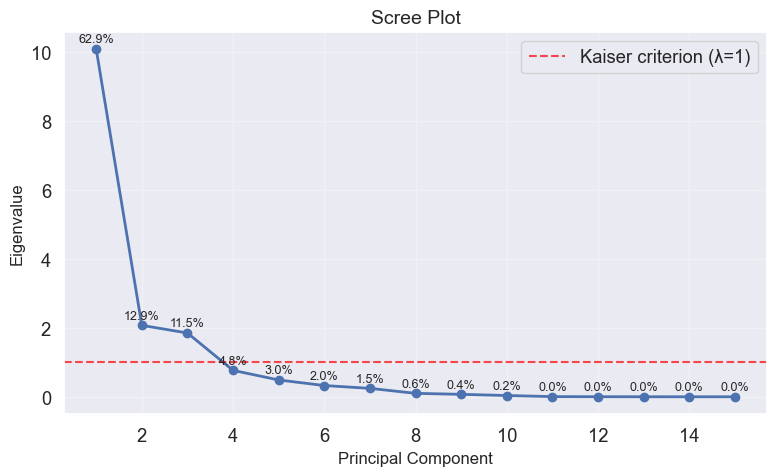

In [31]:
# PCA visualizations (scree plot)
def save_scree_plot(pca_results, filename='scree_plot.svg'):
    """
    Create and save a scree plot from PCA results.
    
    Parameters:
    pca_results : dict
        Dictionary containing 'eigenvalues' and optionally 'explained_variance_ratio'.
    filename : str
        Output filename (should end with .svg).
    """
    eigenvalues = pca_results['eigenvalues']
    
    # Determine number of components to plot (e.g., up to 15 or all)
    n_components = min(15, len(eigenvalues))
    
    # Create a single figure for the scree plot
    plt.figure(figsize=(8, 5))
    
    # Plot eigenvalues
    plt.plot(range(1, n_components + 1), eigenvalues[:n_components], 'bo-', linewidth=2, markersize=6)
    
    # Add Kaiser criterion line (eigenvalue = 1)
    plt.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Kaiser criterion (λ=1)')
    
    # Labels and title
    plt.xlabel('Principal Component', fontsize=12)
    plt.ylabel('Eigenvalue', fontsize=12)
    plt.title('Scree Plot', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Optionally annotate variance explained if available
    if 'explained_variance_ratio' in pca_results:
        var_ratio = pca_results['explained_variance_ratio']
        for i in range(n_components):
            plt.text(i+1, eigenvalues[i]+0.1, f'{var_ratio[i]*100:.1f}%', 
                     ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    # Display the plot
    plt.show()

save_scree_plot(pca_results, filename='scree_plot.svg')
# Example usage (assuming pca_results is already defined):
# save_scree_plot(pca_results, 'my_scree_plot.svg')

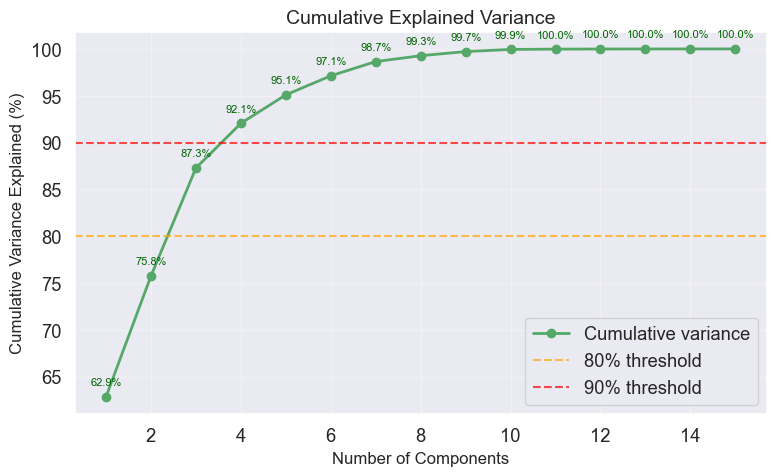

In [33]:
# PCA visualization (cumulative_variance_plot)
def save_cumulative_variance_plot(pca_results, filename='cumulative_variance.svg'):
    """
    Create and save the cumulative explained variance plot from PCA results.
    
    Parameters
    ----------
    pca_results : dict
        Dictionary containing at least 'cumulative_variance' (array of cumulative 
        explained variance ratios, e.g., from PCA analysis). Optionally also 
        contains 'explained_variance_ratio' (not required if cumulative is given).
    filename : str
        Output filename (should end with .svg).
    """
    # Extract cumulative variance (expected as fractions, e.g., 0.629, 0.758, ...)
    cumulative_variance = pca_results['cumulative_variance']
    
    # Determine number of components to plot (up to 15 or all)
    n_components = min(15, len(cumulative_variance))
    
    # Create a single figure
    plt.figure(figsize=(8, 5))
    
    # Plot cumulative variance as percentage
    plt.plot(range(1, n_components + 1), 
             cumulative_variance[:n_components] * 100, 
             'go-', linewidth=2, markersize=6, label='Cumulative variance')
    
    # Add threshold lines
    plt.axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='80% threshold')
    plt.axhline(y=90, color='red', linestyle='--', alpha=0.7, label='90% threshold')
    
    # Labels and title
    plt.xlabel('Number of Components', fontsize=12)
    plt.ylabel('Cumulative Variance Explained (%)', fontsize=12)
    plt.title('Cumulative Explained Variance', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Optionally annotate the exact percentages at each point
    for i in range(n_components):
        plt.text(i+1, cumulative_variance[i]*100 + 1, 
                 f'{cumulative_variance[i]*100:.1f}%', 
                 ha='center', va='bottom', fontsize=8, color='darkgreen')
    
    plt.tight_layout()

    # Display the plot
    plt.show()
save_cumulative_variance_plot(pca_results, filename='cumulative_variance.svg')
# Example usage (assuming pca_results is already available):
# save_cumulative_variance_plot(pca_results, 'cumulative_variance.svg')

In [35]:
# This block has not been implemented for the study; however, it can be used.
'''
def visualize_pca_results(pca_results, feature_names, y, target_names):
    """Create visualizations of PCA results."""
    print(f"\nCreating PCA visualizations...")

    eigenvalues = pca_results['eigenvalues']
    explained_variance_ratio = pca_results['explained_variance_ratio']
    cumulative_variance = pca_results['cumulative_variance']
    X_pca = pca_results['X_pca']
    eigenvectors = pca_results['eigenvectors']

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('PCA Analysis Results', fontsize=14)

    # Plot 1: Scree plot
    n_components = min(15, len(eigenvalues))
    axes[0, 0].plot(range(1, n_components + 1), eigenvalues[:n_components], 'bo-', linewidth=2)
    axes[0, 0].axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Kaiser criterion (λ=1)')
    axes[0, 0].set_xlabel('Principal Component')
    axes[0, 0].set_ylabel('Eigenvalue')
    axes[0, 0].set_title('Scree Plot')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Plot 2: Cumulative explained variance
    axes[0, 1].plot(range(1, n_components + 1), cumulative_variance[:n_components] * 100, 'go-', linewidth=2)
    axes[0, 1].axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='80% threshold')
    axes[0, 1].axhline(y=90, color='red', linestyle='--', alpha=0.7, label='90% threshold')
    axes[0, 1].set_xlabel('Number of Components')
    axes[0, 1].set_ylabel('Cumulative Variance Explained (%)')
    axes[0, 1].set_title('Cumulative Explained Variance')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Plot 3: 2D PCA scatter plot
    colors = ['red' if label == 0 else 'blue' for label in y]
    scatter = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, s=50)
    axes[1, 0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)')
    axes[1, 0].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)')
    axes[1, 0].set_title('2D PCA Projection')
    axes[1, 0].grid(True, alpha=0.3)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='red', alpha=0.6, label='Malignant'),
                      Patch(facecolor='blue', alpha=0.6, label='Benign')]
    axes[1, 0].legend(handles=legend_elements)

    # Plot 4: Component loadings heatmap
    n_pcs_heatmap = 5
    loadings_matrix = eigenvectors[:, :n_pcs_heatmap]

    im = axes[1, 1].imshow(loadings_matrix.T, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    axes[1, 1].set_yticks(range(n_pcs_heatmap))
    axes[1, 1].set_yticklabels([f'PC{i+1}' for i in range(n_pcs_heatmap)])
    axes[1, 1].set_xticks(range(0, len(feature_names), 5))
    axes[1, 1].set_xticklabels([feature_names[i][:8] for i in range(0, len(feature_names), 5)], rotation=45)
    axes[1, 1].set_title('Component Loadings Heatmap')

    plt.colorbar(im, ax=axes[1, 1], shrink=0.8, label='Loading Value')
    plt.tight_layout()
    plt.show()

    # Print key insights
    pc_80 = np.argmax(cumulative_variance >= 0.8) + 1
    pc_90 = np.argmax(cumulative_variance >= 0.9) + 1
    print(f"\nKey Insights:")
    print(f"- {pc_80} components explain 80% of variance")
    print(f"- {pc_90} components explain 90% of variance")
    print(f"- First 2 components explain {cumulative_variance[1]*100:.1f}% of variance")
    print(f"- Good class separation visible in 2D projection")

    return pc_80, pc_90

print("\n" + "=" * 60)
print("PCA VISUALIZATION")
print("=" * 60)

# Create all PCA visualizations
pc_80, pc_90 = visualize_pca_results(pca_results, feature_names, y, target_names)
'''

'\ndef visualize_pca_results(pca_results, feature_names, y, target_names):\n    """Create visualizations of PCA results."""\n    print(f"\nCreating PCA visualizations...")\n\n    eigenvalues = pca_results[\'eigenvalues\']\n    explained_variance_ratio = pca_results[\'explained_variance_ratio\']\n    cumulative_variance = pca_results[\'cumulative_variance\']\n    X_pca = pca_results[\'X_pca\']\n    eigenvectors = pca_results[\'eigenvectors\']\n\n    fig, axes = plt.subplots(2, 2, figsize=(15, 10))\n    fig.suptitle(\'PCA Analysis Results\', fontsize=14)\n\n    # Plot 1: Scree plot\n    n_components = min(15, len(eigenvalues))\n    axes[0, 0].plot(range(1, n_components + 1), eigenvalues[:n_components], \'bo-\', linewidth=2)\n    axes[0, 0].axhline(y=1, color=\'red\', linestyle=\'--\', alpha=0.7, label=\'Kaiser criterion (λ=1)\')\n    axes[0, 0].set_xlabel(\'Principal Component\')\n    axes[0, 0].set_ylabel(\'Eigenvalue\')\n    axes[0, 0].set_title(\'Scree Plot\')\n    axes[0, 0].grid(Tru

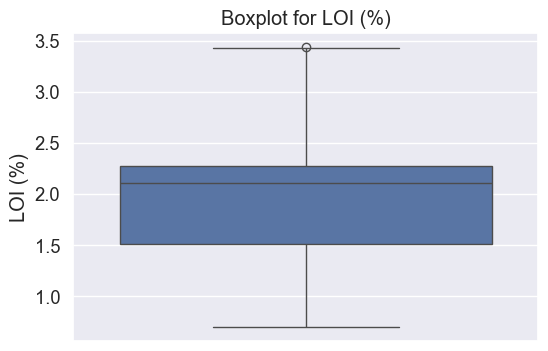

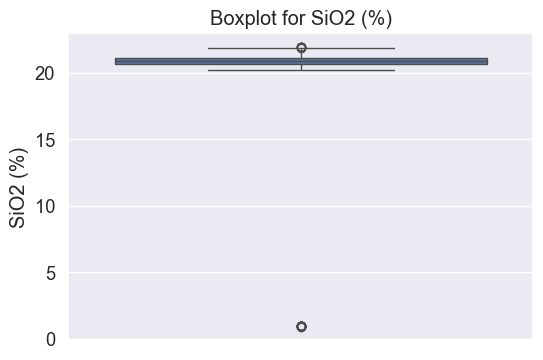

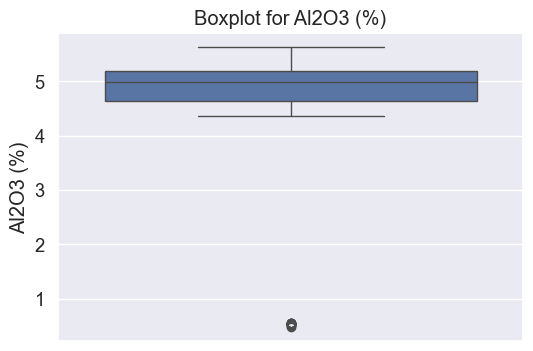

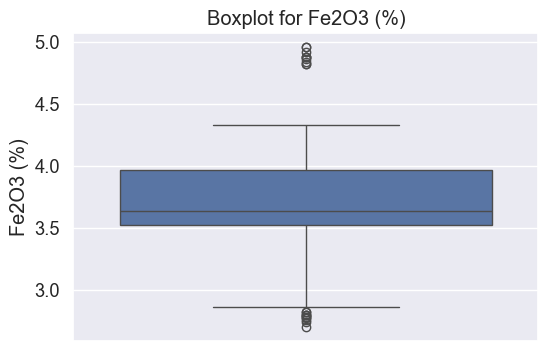

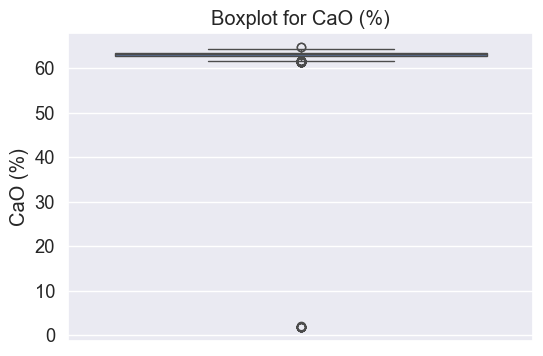

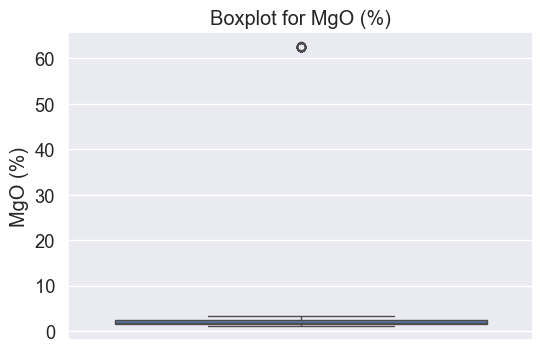

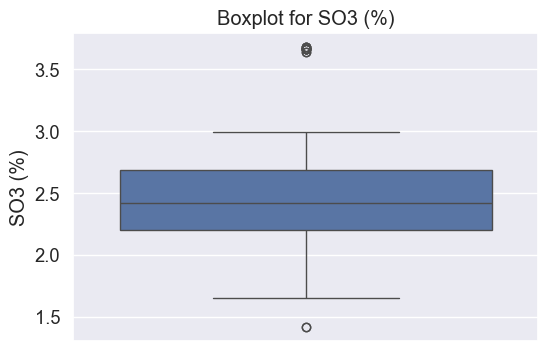

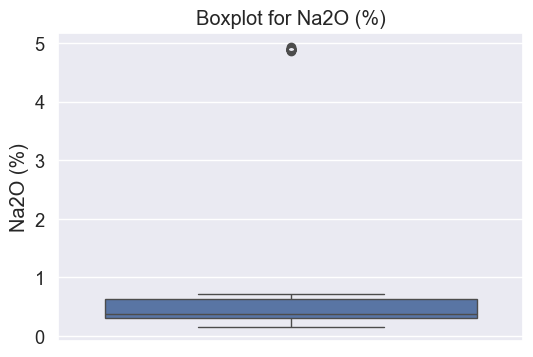

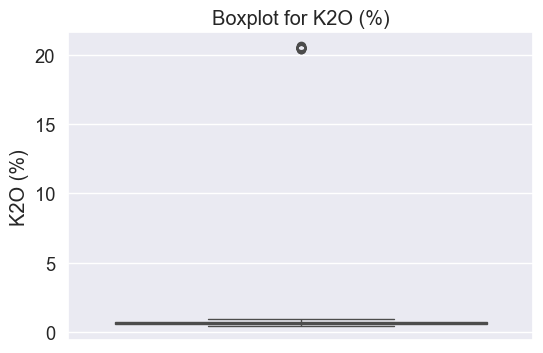

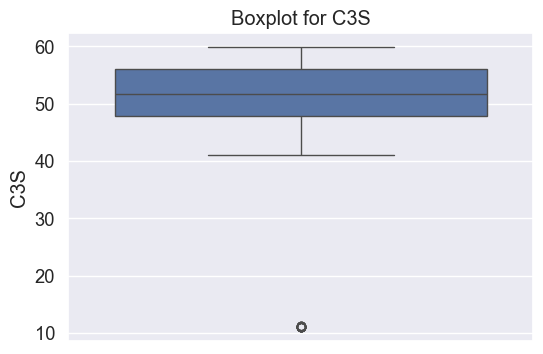

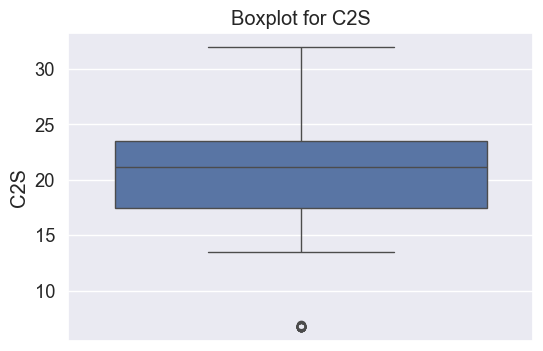

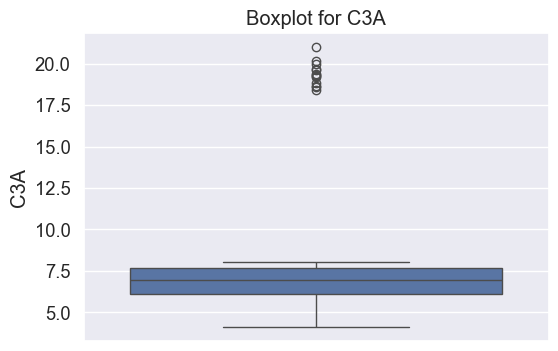

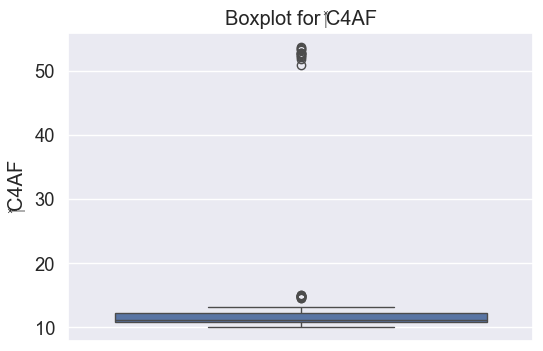

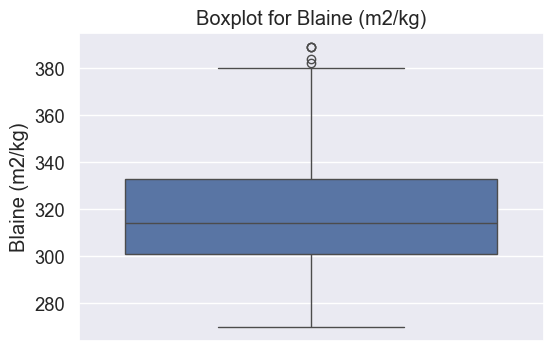

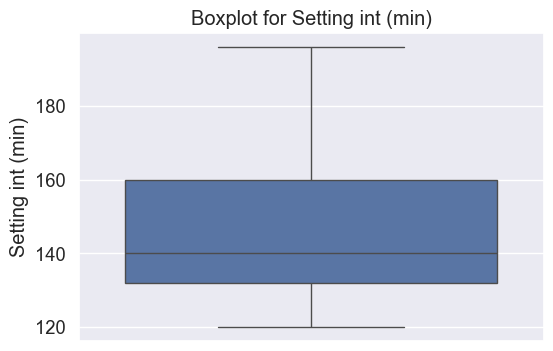

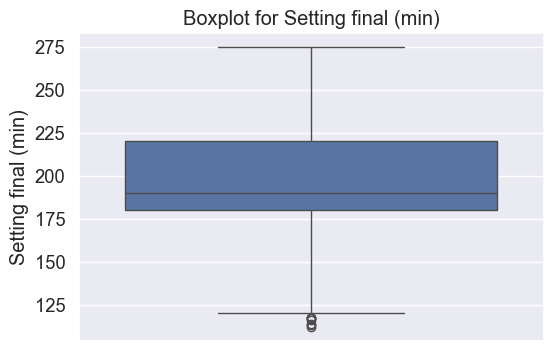

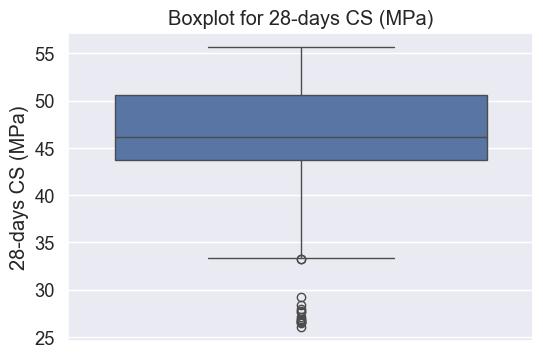

In [37]:
# Box plots:
for column in df_cleaned.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df_cleaned[column])
    plt.title(f'Boxplot for {column}')
    plt.ylabel(column)
    plt.savefig("Box.PNG", bbox_inches="tight")
    plt.show()